Milestone 4 - Incident Type analysis

Objective:

The objective of this milestone is to analyze disaster incident types and understand how different disasters are distributed across states and assistance programs.

This milestone integrates insights from previous milestones including temporal analysis and geographic analysis to provide a complete understanding of disaster patterns in the United States.

1. Load dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("usnd_cleaned.csv")

2️⃣ Incident Type Distribution
📊 Code (Bar Chart)

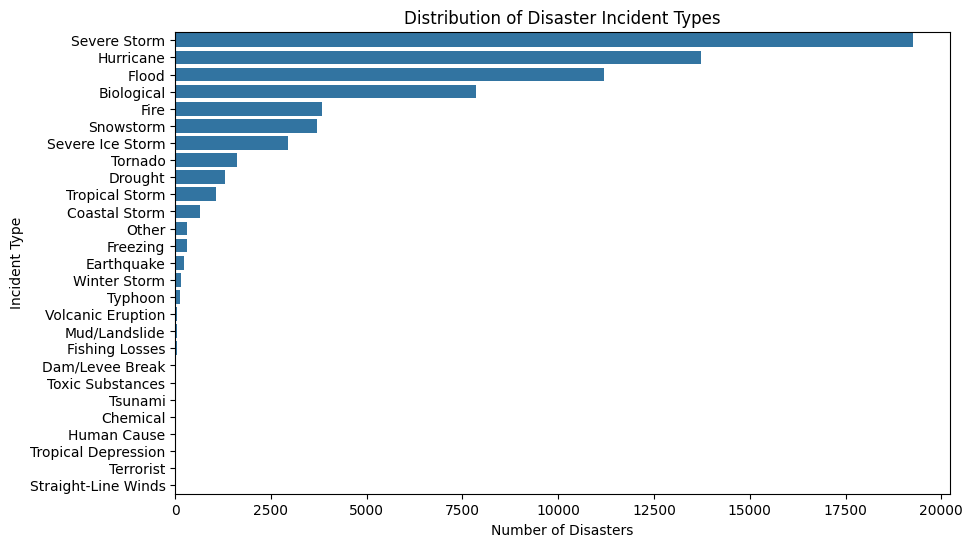

In [2]:
incident_counts = df['incidentType'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=incident_counts.values, y=incident_counts.index)

plt.title("Distribution of Disaster Incident Types")
plt.xlabel("Number of Disasters")
plt.ylabel("Incident Type")

plt.show()

pie chart

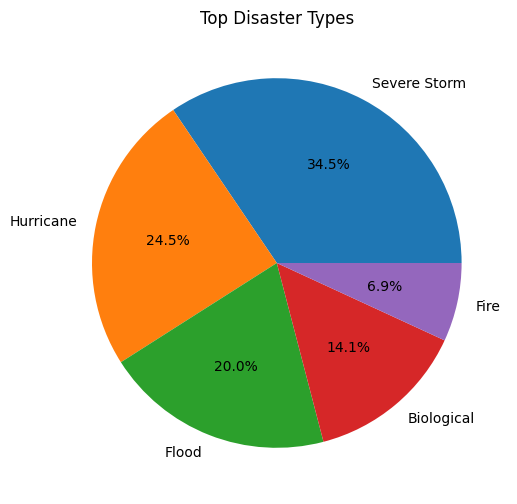

In [3]:
incident_counts.head(5).plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Top Disaster Types")
plt.ylabel("")
plt.show()

What it shows?-->
Total number of disasters for each incident type.
Pattern-->
Storms, floods, and fires usually dominate.
Reason-->
These disasters occur frequently due to weather conditions.

3. State vs Incident Type (Stacked Bar)

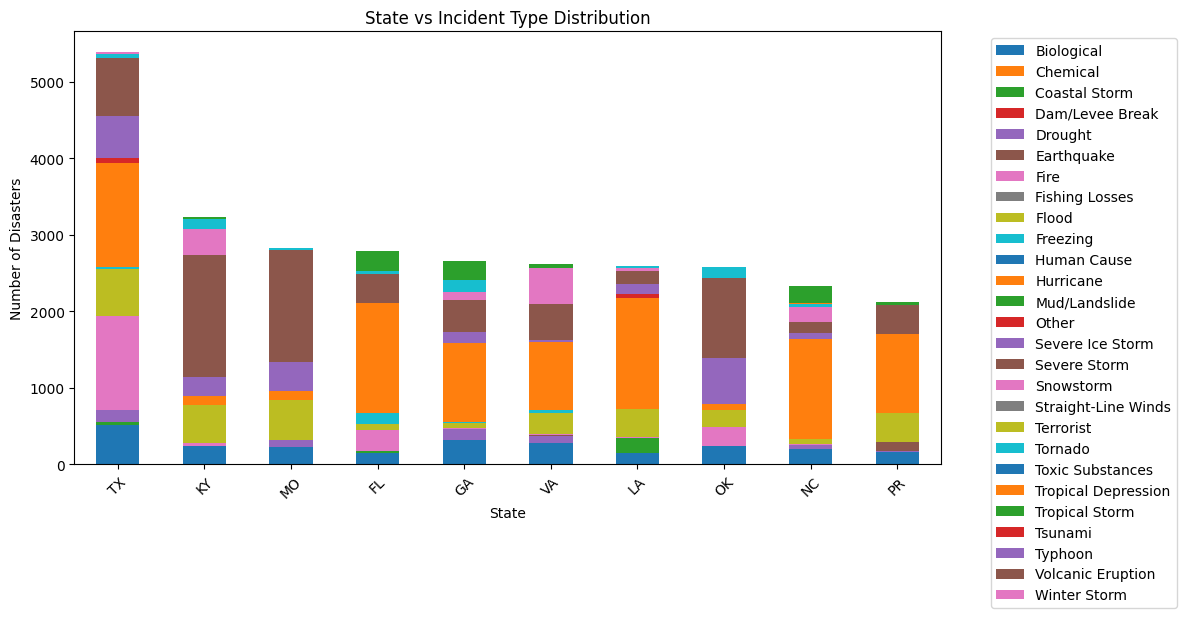

In [4]:
state_incident = df.groupby(['state','incidentType']).size().reset_index(name='count')

pivot_data = state_incident.pivot(index='state', columns='incidentType', values='count').fillna(0)

top_states = df['state'].value_counts().head(10).index
pivot_data = pivot_data.loc[top_states]

pivot_data.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("State vs Incident Type Distribution")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()


What it shows?
Different disaster types in each state.
Pattern-->
Each state has dominant disaster types.
Reason-->
Geography and climate affect disaster type.

4. Heatmap

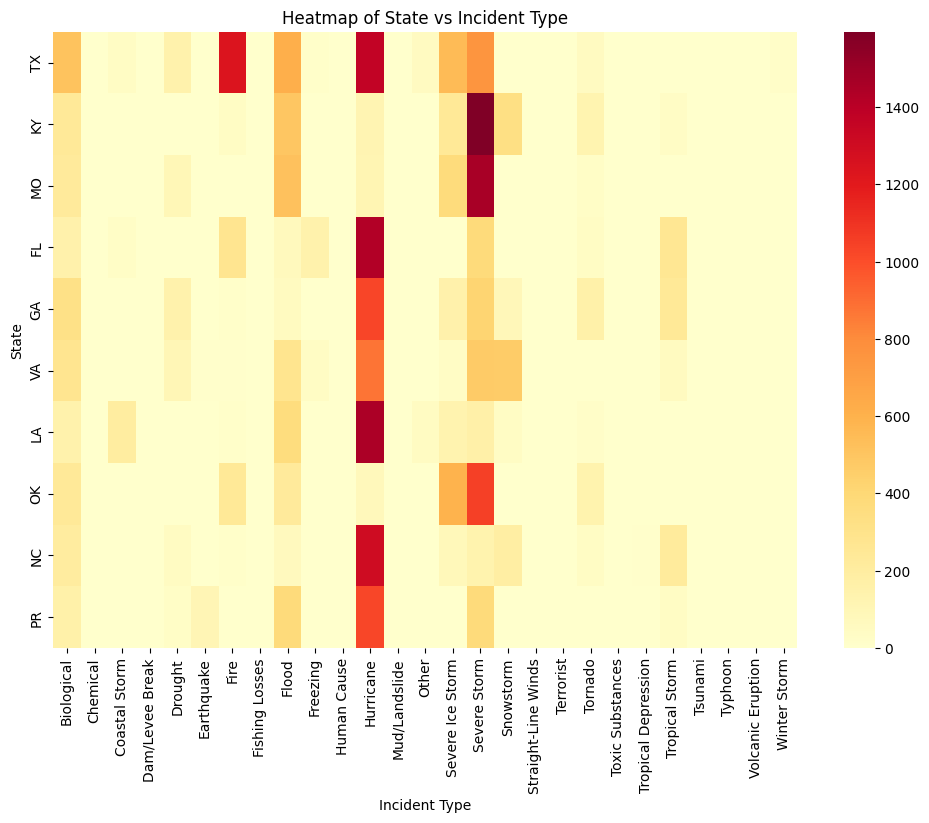

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(pivot_data, cmap="YlOrRd")

plt.title("Heatmap of State vs Incident Type")
plt.xlabel("Incident Type")
plt.ylabel("State")

plt.show()

Explanation

What it shows?
Intensity of disaster types across states.

Pattern-->
Some states show high concentration of specific disasters

5. Assistance Program Analysis

In [10]:
df.rename(columns={
    'incident_type':'incidentType',
    'ih_program_declared':'ihProgramDeclared',
    'pa_program_declared':'paProgramDeclared'
}, inplace=True)

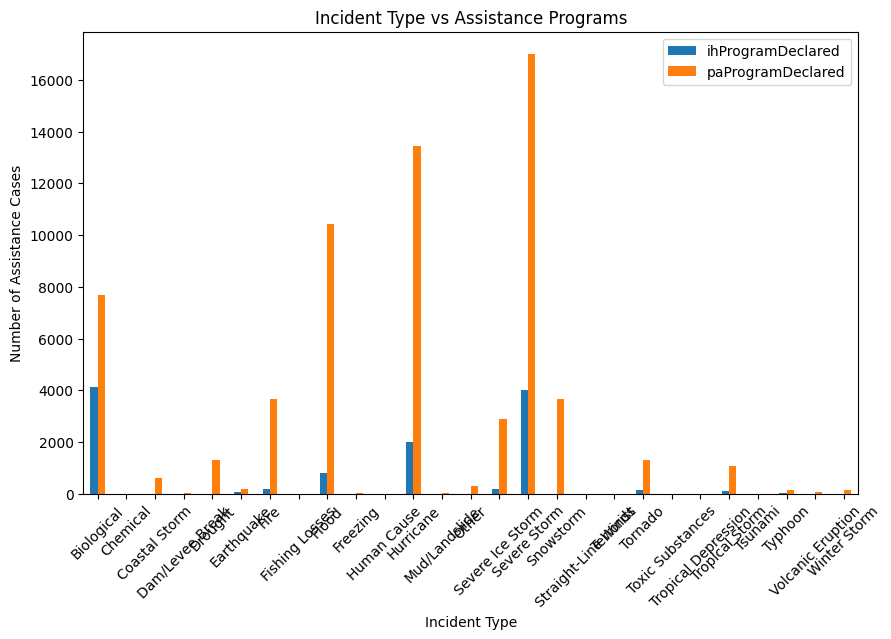

In [12]:
assistance = df.groupby('incidentType')[['ihProgramDeclared','paProgramDeclared']].sum()

assistance.plot(kind='bar', figsize=(10,6))

plt.title("Incident Type vs Assistance Programs")
plt.xlabel("Incident Type")
plt.ylabel("Number of Assistance Cases")

plt.xticks(rotation=45)
plt.show()

Representation:
Relationship between disaster types and assistance programs

Pattern:
Some disasters trigger more assistance than others

Reason:
Severe disasters like hurricanes and floods cause more damage

What it shows
Which disasters trigger government assistance.

Pattern
Major disasters trigger more assistance

Final Insights:
*Storms and floods are the most frequent disaster types.
*Certain states experience repeated disasters due to geographic conditions.
*Disaster frequency has increased over time.
*Severe disasters trigger higher government assistance programs